In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("C:\\Users\\manas\\Downloads\\dummy_data.csv")
df.head(10)

,Year,Exam_Date,Name,Category,Sex,State,Maths_Marks,Physics_Marks,Chemistry_Marks,Total_Marks,Rank,Percentile
0,2013,2013-04-21,Tristan Bhandari,General,F,Uttar Pradesh,75,83,48,206,78,51.572327
1,2013,2013-04-18,Rehaan Rajagopalan,General,M,Rajasthan,71,85,62,218,66,59.119497
2,2013,2013-04-19,Yatin Natarajan,General,F,Rajasthan,67,94,73,234,50,69.182390
3,2013,2013-04-21,Peter Bhalla,Reserved,F,Uttar Pradesh,52,71,66,189,85,39.130435
4,2013,2013-04-17,Jairaj Mannan,General,M,Gujarat,40,65,65,170,114,28.930818
5,2013,2013-04-19,Aradhana Bumb,General,F,Tamil Nadu,99,75,50,224,60,62.893082
6,2013,2013-04-19,Jasmit Shenoy,General,F,Maharashtra,95,96,31,222,62,61.635220
7,2013,2013-04-21,Nidra Bali,General,M,Madhya Pradesh,74,92,60,226,58,64.150943
8,2013,2013-04-16,Yahvi Rattan,Reserved,M,West Bengal,87,48,59,194,80,42.753623
9,2013,2013-04-17,Geetika Char,Reserved,M,Rajasthan,69,70,73,212,62,55.797101


In [115]:
#CONVERTING INTO DATETIME
df['Exam_Date']=pd.to_datetime(df['Exam_Date'])
print(df.columns)
df.dtypes

Index(['Year', 'Exam_Date', 'Name', 'Category', 'Sex', 'State', 'Maths_Marks',
       'Physics_Marks', 'Chemistry_Marks', 'Total_Marks', 'Rank',
       'Percentile'],
      dtype='object')


Year                        int64
Exam_Date          datetime64[ns]
Name                       object
Category                   object
Sex                        object
State                      object
Maths_Marks                 int64
Physics_Marks               int64
Chemistry_Marks             int64
Total_Marks                 int64
Rank                        int64
Percentile                float64
dtype: object

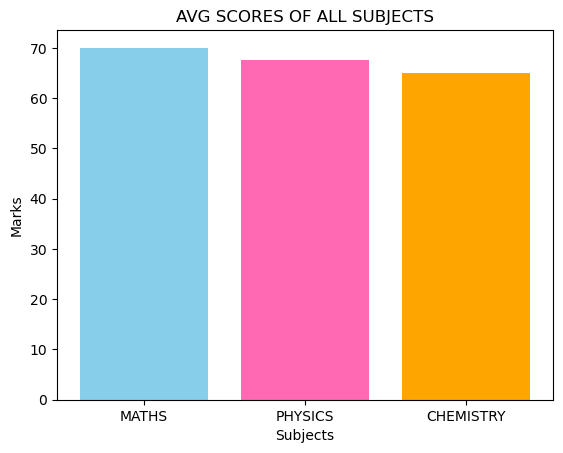

In [8]:
col=['MATHS','PHYSICS','CHEMISTRY']
avg_mathma=df['Maths_Marks'].mean()
avg_phyma=df['Physics_Marks'].mean()
avg_chemma=df['Chemistry_Marks'].mean()
tot=[avg_mathma,avg_phyma,avg_chemma]
plt.bar(col,tot,color=['skyblue','hotpink','orange'])
plt.xlabel('Subjects')
plt.ylabel('Marks')
plt.title('AVG SCORES OF ALL SUBJECTS')
plt.show()


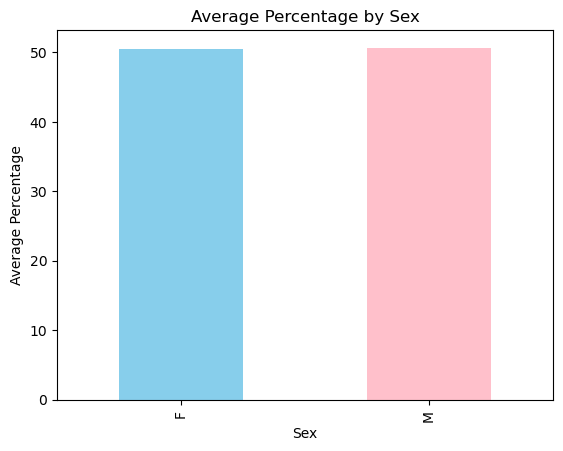

In [75]:
sex_avg=df.groupby(df['Sex'])['Percentile'].mean().round(2)
sex_avg.plot(kind='bar',color=['skyblue', 'pink'])
plt.ylabel('Average Percentage')
plt.title('Average Percentage by Sex')
plt.show()

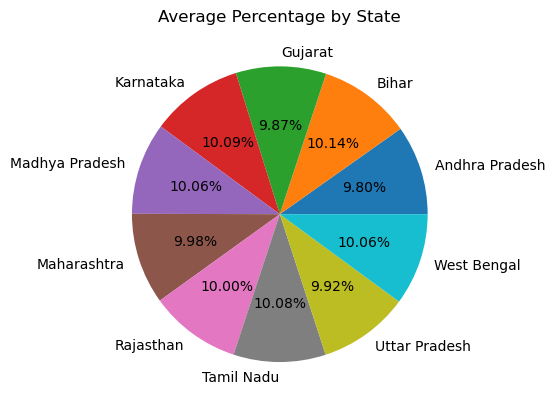

In [9]:
state=df.groupby(df['State'])['Percentile'].mean().round(2)
plt.pie(state.values ,labels=state.index, autopct='%1.2f%%')
plt.title('Average Percentage by State')
plt.show()

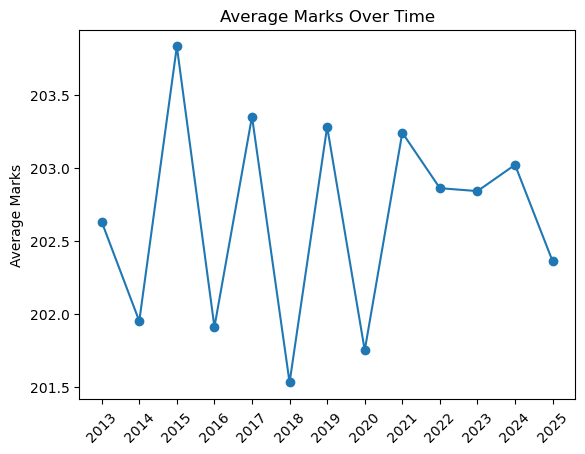

In [31]:
date=df.groupby(df['Year'])['Total_Marks'].mean().round(2)
plt.plot(date.index,date.values,marker='o')
plt.ylabel('Average Marks')
plt.title('Average Marks Over Time')
x=df.groupby(df['Year'])['Total_Marks'].mean().round(2).index

plt.xticks(x,rotation=45)
plt.show()


In [109]:
numeric_columns= ['Maths_Marks',
       'Physics_Marks', 'Chemistry_Marks', 'Total_Marks', 'Rank',
       'Percentile']
corr=df[numeric_columns].corr()
corr

,Maths_Marks,Physics_Marks,Chemistry_Marks,Total_Marks,Rank,Percentile
Maths_Marks,1.000000,-0.006215,0.003657,0.529940,-0.524380,0.528548
Physics_Marks,-0.006215,1.000000,0.003287,0.574459,-0.567917,0.572617
Chemistry_Marks,0.003657,0.003287,1.000000,0.624611,-0.618881,0.623454
Total_Marks,0.529940,0.574459,0.624611,1.000000,-0.989723,0.997482
Rank,-0.524380,-0.567917,-0.618881,-0.989723,1.000000,-0.989446
Percentile,0.528548,0.572617,0.623454,0.997482,-0.989446,1.000000


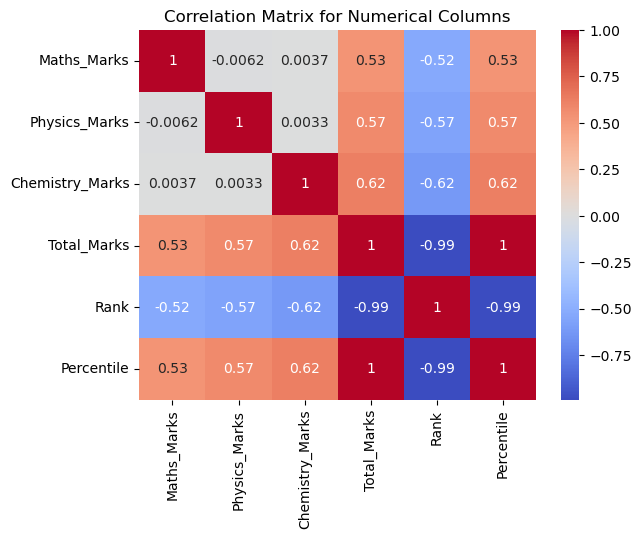

In [117]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix for Numerical Columns')
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['Sex_Encoded']=pd.factorize(df['Sex'])[0]
df['Category_Encoded']=le.fit_transform(df['Category'])
print(dict(zip(le.classes_,le.fit_transform(le.classes_))))
print('-'*150)
df['State_Encoded']=le.fit_transform(df['State'])
print(dict(zip(le.classes_,le.fit_transform(le.classes_))))
print('-'*150)
le.classes_

{'General': 0, 'Reserved': 1}
------------------------------------------------------------------------------------------------------------------------------------------------------
{'Andhra Pradesh': 0, 'Bihar': 1, 'Gujarat': 2, 'Karnataka': 3, 'Madhya Pradesh': 4, 'Maharashtra': 5, 'Rajasthan': 6, 'Tamil Nadu': 7, 'Uttar Pradesh': 8, 'West Bengal': 9}
------------------------------------------------------------------------------------------------------------------------------------------------------


array(['Andhra Pradesh', 'Bihar', 'Gujarat', 'Karnataka',
       'Madhya Pradesh', 'Maharashtra', 'Rajasthan', 'Tamil Nadu',
       'Uttar Pradesh', 'West Bengal'], dtype=object)